In [33]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from copy import deepcopy
import pickle as pkl

from matplotlib import pyplot as plt
import matplotlib as mpl

from scipy.spatial.distance import cdist

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from umap import UMAP

from model import DNN
from run_sim import Config, run_sim, create_data, train_model, run_sim_wrapper

from utils import *
from utils_plot import *

from tqdm import tqdm


In [34]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [35]:
def multiclass_functional_margin(W, X, y, reducer=np.min):
    W = W / np.linalg.norm(W)
    margins = []
    i_max_other_score_l = []
    for x, y_curr in zip(X, y):
        label = y_curr.argmax()
        scores = x@W  # shape (K,)
        true_score = scores[label]
        max_other_score = np.max(np.delete(scores, label))
        i_max_other_score = np.argmax(np.delete(scores, label))
        margins.append(true_score - max_other_score)
        i_max_other_score_l.append(i_max_other_score)
    return reducer(margins), np.argmin(margins), i_max_other_score_l[np.argmin(margins)]

In [36]:
C = Config()

C.G = 0.8
C.sig_h_2 = 1e-3
# C.gpu_id=1
# C.seed = 1
C.linear_net = True
# C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 0.001
C.L=5
C.print_progress = False
C.length_corridors = [5]*1
# C.input_size = 100
C.max_move = C.length_corridors[0]//2
C.hidden_size = 100 # C.length_corridors[0] * 2 + 1 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 1000000
C.algo_name = 'SGD'
C.loss_fn = nn.CrossEntropyLoss()

 20%|██        | 1/5 [08:57<35:48, 537.10s/it]

Min margin sample: loc_X: 2, action_taken: 0, loc_y: 2, i_max_other_score: 1


 40%|████      | 2/5 [20:55<32:11, 643.95s/it]

Min margin sample: loc_X: 3, action_taken: 1, loc_y: 4, i_max_other_score: 3


 60%|██████    | 3/5 [36:42<26:04, 782.32s/it]

Min margin sample: loc_X: 3, action_taken: 1, loc_y: 4, i_max_other_score: 3


 80%|████████  | 4/5 [56:04<15:32, 932.05s/it]

Min margin sample: loc_X: 1, action_taken: -1, loc_y: 0, i_max_other_score: 0


100%|██████████| 5/5 [1:18:16<00:00, 939.20s/it] 

Min margin sample: loc_X: 4, action_taken: -2, loc_y: 2, i_max_other_score: 1


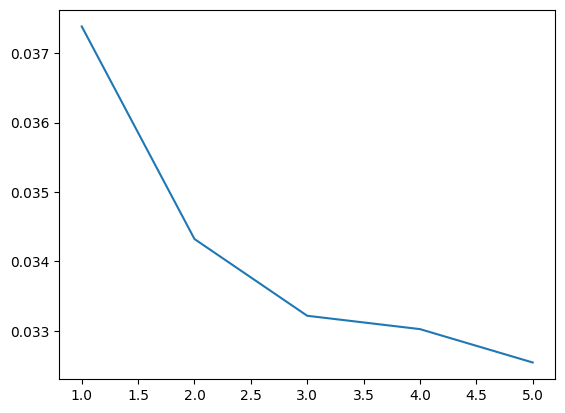

In [37]:
# var_name = 'max_move'
# var_values = np.linspace(1,  C.length_corridors[0], 1).astype(int)
var_name = 'L'
var_values = np.linspace(1,  5, 5).astype(int)
# learning_rates = np.linspace(0.1,  0.01, len(var_values)).astype(float)
W_l = []
margins_l = []
min_margin_idx_l = []
data_dict_l = []
for i, var_value in enumerate(tqdm(var_values)):
    C = deepcopy(C)
    setattr(C, var_name, var_value)
    # C.learning_rate = learning_rates[i]

    data_dict = run_sim_wrapper(C)
    
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    action_taken = data_dict['action_taken']
    loc_y = data_dict['loc_y']
    loc_X = data_dict['loc_X']

    margins, min_margin_idx, i_max_other_score = multiclass_functional_margin(W, X, y)
    W_l.append(W)
    margins_l.append(margins)
    min_margin_idx_l.append(min_margin_idx)
    data_dict_l.append(data_dict)
    print(f'Min margin sample: loc_X: {loc_X[min_margin_idx]}, action_taken: {action_taken[min_margin_idx]}, loc_y: {loc_y[min_margin_idx]}, i_max_other_score: {i_max_other_score}')

plt.plot(var_values, margins_l)
plt.show()

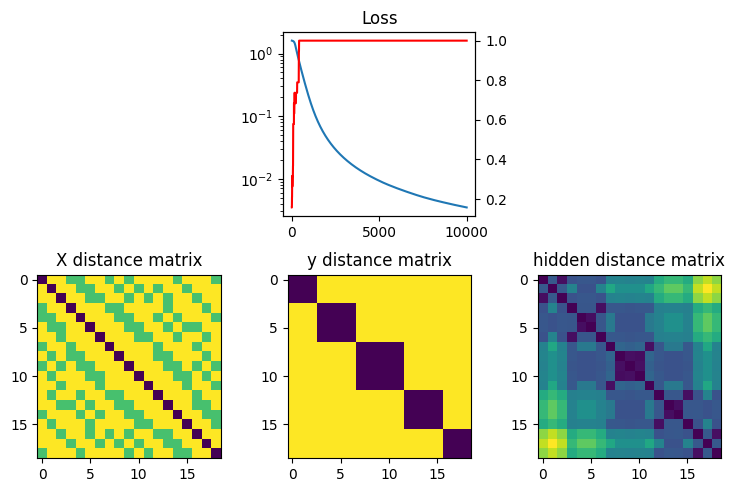

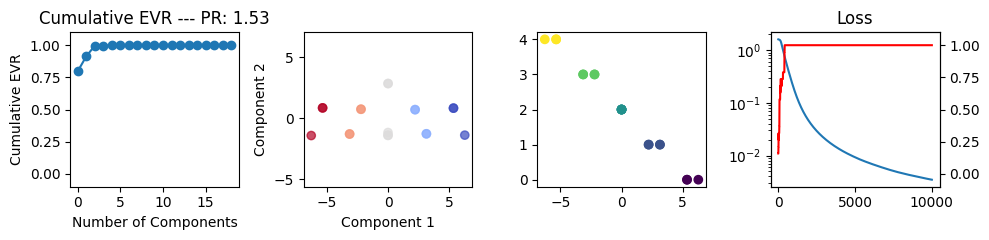

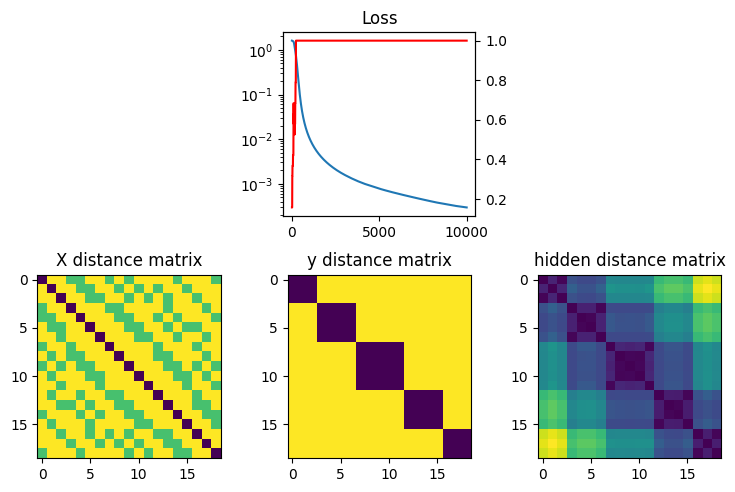

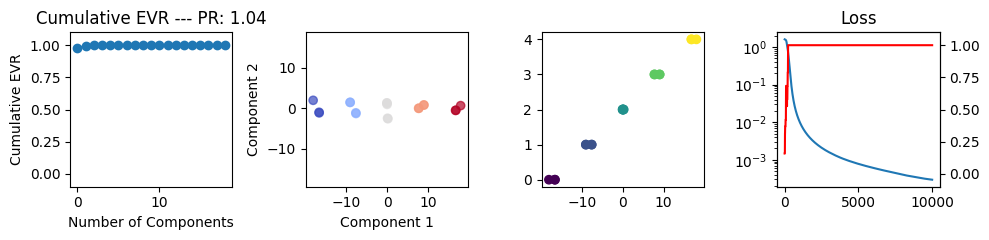

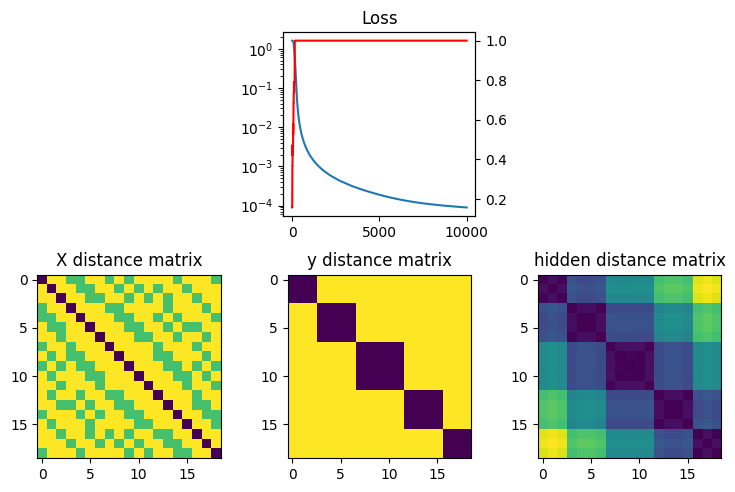

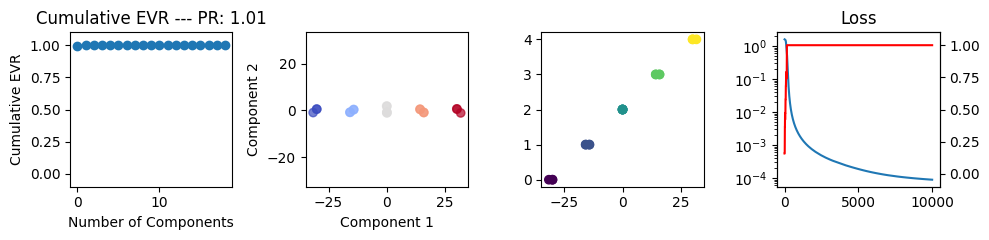

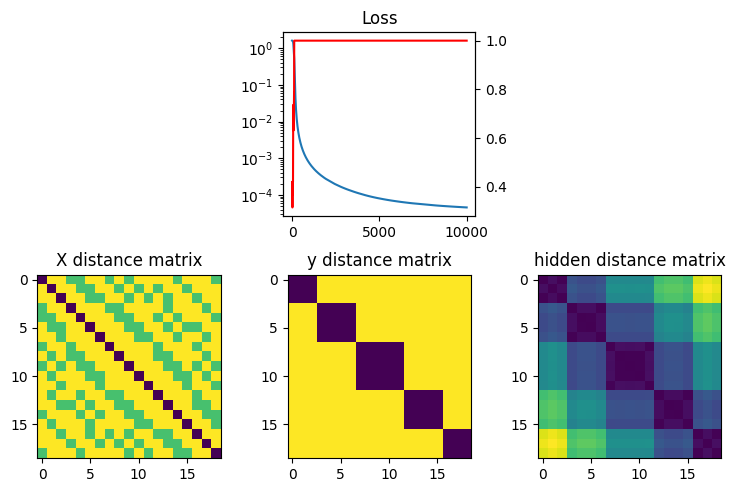

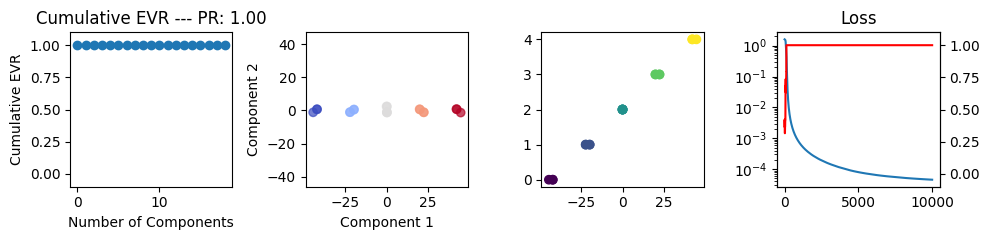

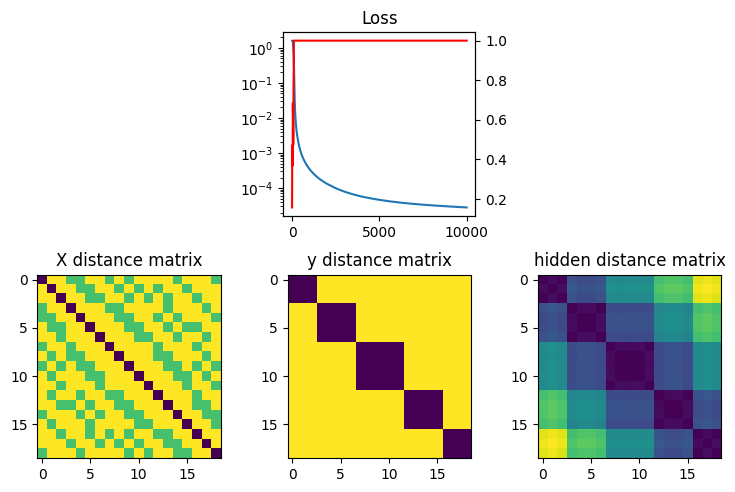

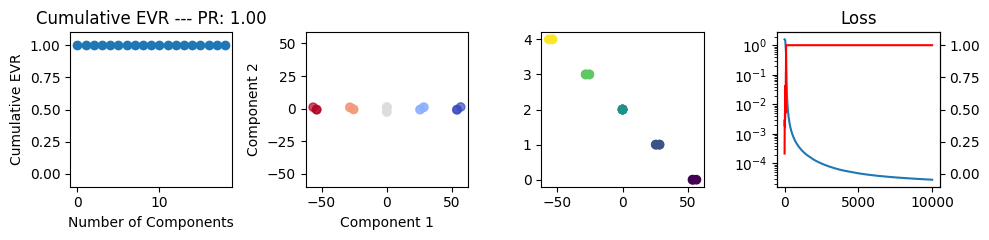

In [38]:
for data_dict in data_dict_l:
    plot_loss_and_dist(data_dict)
    plot_pca(data_dict)

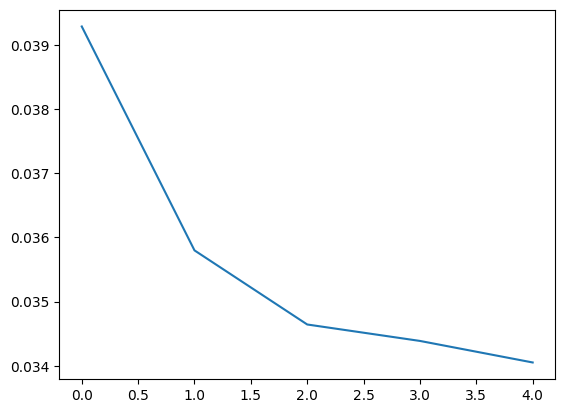

In [39]:
margins_l = []
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    state_dict = data_dict['final_weights']
    W = get_effective_W_from_model_dict(state_dict).cpu().numpy()
    margins, min_margin_idx, i_max_other_score = multiclass_functional_margin(W, X, y, reducer=np.mean)
    margins_l.append(margins)

plt.plot(margins_l)
plt.show()

Cosine similarity matrix between all theta in theta_l:


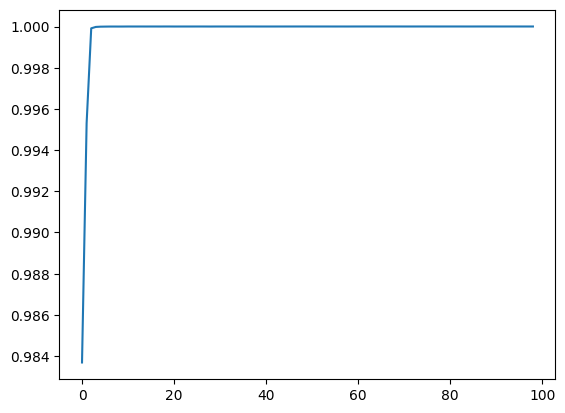

In [40]:
state_dict_l = data_dict['state_dict_l']
theta_l = [state_dict_to_theta(state_dict)[0].cpu().numpy() for state_dict in state_dict_l]

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Stack all theta vectors into a 2D array
theta_mat = np.stack(theta_l)
# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(theta_mat)
print("Cosine similarity matrix between all theta in theta_l:")
plt.plot(np.diag(similarity_matrix, 1))









